In [7]:
!pip install --upgrade optbinning

  Using cached optbinning-0.21.0-py3-none-any.whl.metadata (2.1 kB)
INFO: pip is looking at multiple versions of optbinning to determine which version is compatible with other requirements. This could take a while.
  Using cached optbinning-0.20.1-py3-none-any.whl.metadata (2.1 kB)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import csv
import matplotlib.pyplot as plt
import optuna
from sklearn import metrics
import scipy.stats as stats
import phik

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import roc_curve, confusion_matrix
from pandas.api.types import is_string_dtype
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils import resample
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from optbinning import BinningProcess
from tqdm import tqdm
from catboost import CatBoostClassifier

TARGET = 'target'
ID_COL = 'reco_id_curr'
RANDOM_STATE = 42

def gini(y_true, y_pred):
    auc = roc_auc_score(y_true, y_pred)
    return 2 * auc  - 1

def ks_score(y_true, y_score):
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score)
    return max(tpr - fpr)


In [2]:
best_parameters_for_log_reg = {'C': 10.0, 'class_weight': 'balanced', 'max_iter' : 1000, 'random_state': RANDOM_STATE}
best_parameters_for_knn = { 'n_neighbors' : 1500 }
best_parameters_for_rf = {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 5, 'class_weight': None, 'random_state': RANDOM_STATE}
best_parameters_for_cb = {
    'iterations' : 500,
    'learning_rate' : 0.1,
    'depth' : 5,
    'random_state' : RANDOM_STATE
}

In [3]:
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
X_late = pd.read_csv('X_late.csv')

X_train_cb = pd.read_csv('X_train_cb.csv')
X_val_cb = pd.read_csv('X_val_cb.csv')
X_test_cb = pd.read_csv('X_test_cb.csv')
X_late_cb = pd.read_csv('X_late_cb.csv')

y_train = pd.read_csv('y_train').squeeze('columns')
y_val = pd.read_csv('y_val').squeeze('columns')
y_test = pd.read_csv('y_test').squeeze('columns')
y_late = pd.read_csv('y_late').squeeze('columns')

y_train_cb = pd.read_csv('y_train_cb').squeeze('columns')
y_val_cb = pd.read_csv('y_val_cb').squeeze('columns')
y_test_cb = pd.read_csv('y_test_cb').squeeze('columns')
y_late_cb = pd.read_csv('y_late_cb').squeeze('columns')

In [4]:
model_LogReg = LogisticRegression(**best_parameters_for_log_reg)
model_KNN = KNeighborsClassifier(**best_parameters_for_knn)
model_RF = RandomForestClassifier(**best_parameters_for_rf)
model_cb = CatBoostClassifier(**best_parameters_for_cb, cat_features=(X_train_cb.select_dtypes(include=['object', 'str']).columns).tolist())

model_LogReg.fit(X_train, y_train)
print("Logistic Regression.") 
# print("Лучшие праметры: С = 10, class_weight = balanced, max_iter = 1000")
probabilities = model_LogReg.predict_proba(X_val)[:,1]
print('val', gini(y_val, probabilities))
print(ks_score(y_val, probabilities))
probabilities = model_LogReg.predict_proba(X_test)[:,1]
print('test', gini(y_test, probabilities))
print(ks_score(y_test, probabilities))
probabilities = model_LogReg.predict_proba(X_late)[:,1]
print('late', gini(y_late, probabilities))
print(ks_score(y_late, probabilities))

model_KNN.fit(X_train, y_train)
print("K-Nearest Neighbors.") 
print("Удалён как слишком безопасный.")
# # print("Лучшие праметры: n_neighbors = 1500")
# probabilities = model_KNN.predict_proba(X_val)[:,1]
# print('val', gini(y_val, probabilities))
# probabilities = model_KNN.predict_proba(X_test)[:,1]
# print('test', gini(y_test, probabilities))
# probabilities = model_KNN.predict_proba(X_late)[:,1]
# print('late', gini(y_late, probabilities))

model_RF.fit(X_train, y_train)
print("Random Forest.")
# print("Лучшие праметры: n_estimators = 300, max_depth = 15, min_samples_leaf = 5, class_weight = None, random_state = 42")
probabilities = model_RF.predict_proba(X_val)[:,1]
print('val', gini(y_val, probabilities))
print(ks_score(y_val, probabilities))
probabilities = model_RF.predict_proba(X_test)[:,1]
print('test', gini(y_test, probabilities))
print(ks_score(y_test, probabilities))
probabilities = model_RF.predict_proba(X_late)[:,1]
print('late', gini(y_late, probabilities))
print(ks_score(y_late, probabilities))


model_cb.fit(X_train_cb, y_train_cb, verbose=False)
print("Catboost.")
probabilities = model_cb.predict_proba(X_val_cb)[:,1]
print('val', gini(y_val_cb, probabilities))
print(ks_score(y_val_cb, probabilities))
probabilities = model_cb.predict_proba(X_test_cb)[:,1]
print('test', gini(y_test_cb, probabilities))
print(ks_score(y_test_cb, probabilities))
probabilities = model_cb.predict_proba(X_late_cb)[:,1]
print('late', gini(y_late_cb, probabilities))
print(ks_score(y_late_cb, probabilities))

Logistic Regression.
val 0.4543177072348339
0.328989300855114
test 0.47448763233807
0.3593808456991159
late 0.4789530897279328
0.3578882363969436
K-Nearest Neighbors.
Удалён как слишком безопасный.
Random Forest.
val 0.4535346019405624
0.3389180607754356
test 0.4665501067403264
0.358070885564141
late 0.4791958321872398
0.36082259869105027
Catboost.
val 0.5218615536969771
0.3955800620208994
test 0.49999506080581835
0.39223450229238743
late 0.5059438392458127
0.3747522135276095



Оцениваем модель: LogReg

Оцениваем модель: Random Forest

Оцениваем модель: CatBoost


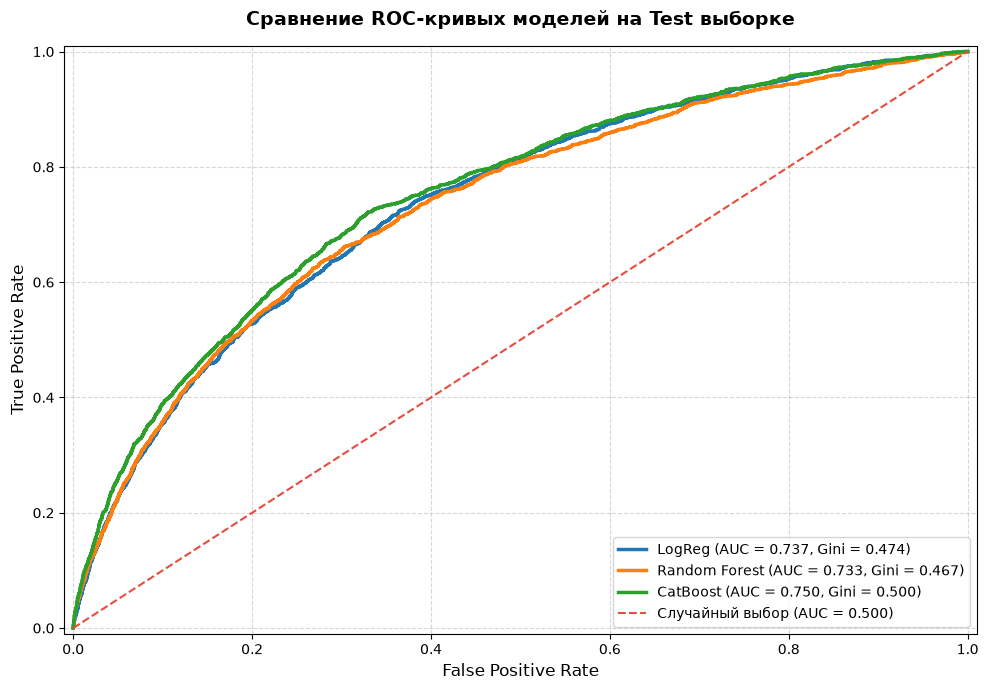


СРЕДНЕЕ ЗНАЧЕНИЕ GINI ПО ТРЕМ ВЫБОРКАМ:
Модель: CatBoost        | Средний Gini: 0.5093
Модель: LogReg          | Средний Gini: 0.4693
Модель: Random Forest   | Средний Gini: 0.4664



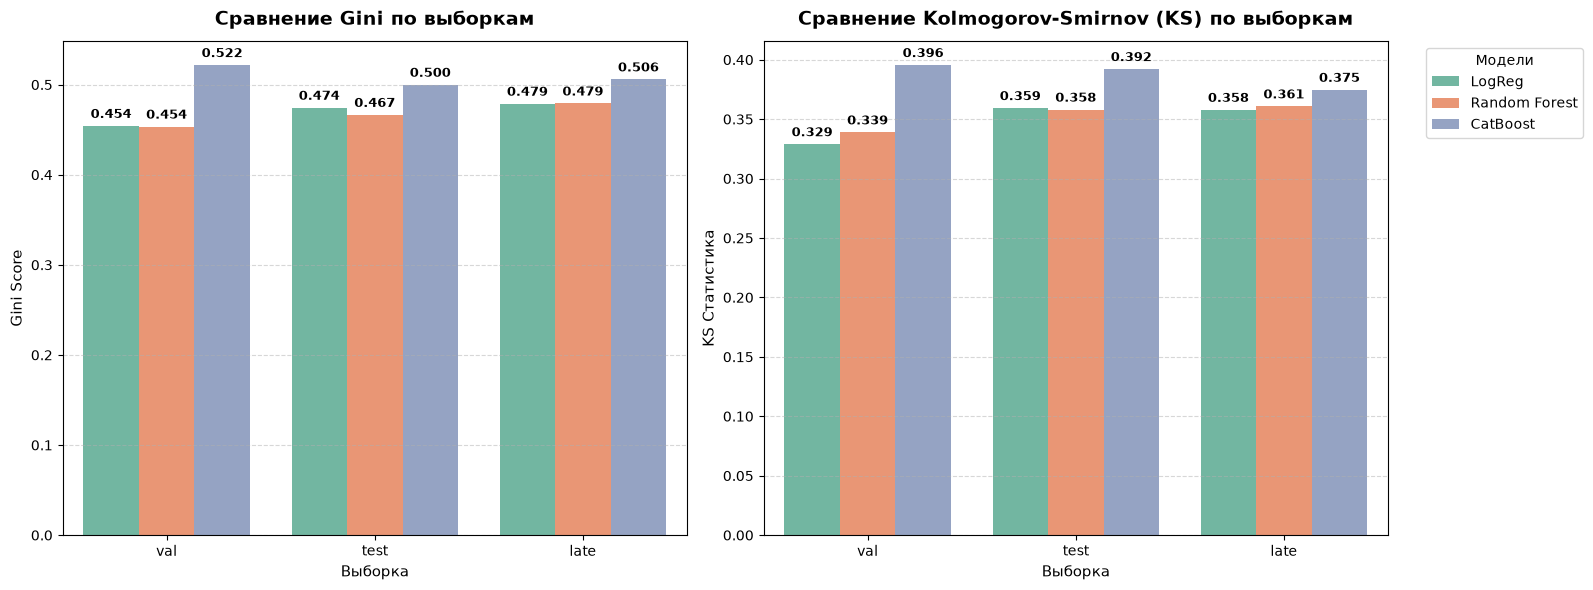

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# --- ШАГ 1. СБОР МЕТРИК И СРАВНЕНИЕ ROC-КРИВЫХ ---

# Списки для сохранения результатов
models_dict = {
    'LogReg': (model_LogReg, X_train, X_val, X_test, X_late),
    'Random Forest': (model_RF, X_train, X_val, X_test, X_late),
    'CatBoost': (model_cb, X_train_cb, X_val_cb, X_test_cb, X_late_cb)
}

metrics_records = []

# Создаем фигуру для первого графика (ROC-кривые)
plt.figure(figsize=(10, 7), facecolor='white')

# Словарь таргетов для базовых моделей
targets = {'val': y_val, 'test': y_test, 'late': y_late}

for name, (model, tr_x, val_x, test_x, late_x) in models_dict.items():
    print(f"\nОцениваем модель: {name}")
    
    # Обучаем модель (если не была обучена ранее)
    if name == 'CatBoost':
        model.fit(tr_x, y_train_cb, verbose=False)
    else:
        model.fit(tr_x, y_train)
        
    datasets = {'val': val_x, 'test': test_x, 'late': late_x}
    
    for split_name, dataset in datasets.items():
        # Считаем вероятности дефолта
        probs = model.predict_proba(dataset)[:, 1]
        
        # Определяем правильный таргет для CatBoost и остальных
        if name == 'CatBoost':
            current_target = y_val_cb if split_name == 'val' else (y_test_cb if split_name == 'test' else y_late_cb)
        else:
            current_target = targets[split_name]
        
        # Считаем метрики качества
        g_score = gini(current_target, probs)
        k_score = ks_score(current_target, probs)
        
        # Сохраняем данные в список
        metrics_records.append({
            'Model': name, 'Split': split_name, 'Gini': g_score, 'KS': k_score
        })
        
        # Для ROC-кривой берем только TEST выборку
        if split_name == 'test':
            fpr, tpr, _ = roc_curve(current_target, probs)
            auc_val = roc_auc_score(current_target, probs)
            plt.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {auc_val:.3f}, Gini = {g_score:.3f})')

# Оформление графика ROC-кривых
plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', label='Случайный выбор (AUC = 0.500)')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Сравнение ROC-кривых моделей на Test выборке', fontsize=14, pad=15, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()


# --- ШАГ 2. ВЫВОД СРЕДНИХ И СТРОИМ СГРУППИРОВАННЫЕ СТОЛБЦЫ ---

# Создаем DataFrame из собранных данных
df_metrics = pd.DataFrame(metrics_records)

# Расчет и вывод среднего Gini по 3-м выборкам для каждой модели
print("\n" + "="*50)
print("СРЕДНЕЕ ЗНАЧЕНИЕ GINI ПО ТРЕМ ВЫБОРКАМ:")
print("="*50)
mean_gini = df_metrics.groupby('Model')['Gini'].mean().reset_index()
for index, row in mean_gini.iterrows():
    print(f"Модель: {row['Model']:<15} | Средний Gini: {row['Gini']:.4f}")
print("="*50 + "\n")

# Настраиваем сетку из двух графиков side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False, facecolor='white')

# 1. Левый график: Сравнение Gini
sns.barplot(data=df_metrics, x='Split', y='Gini', hue='Model', ax=axes[0], palette='Set2')
axes[0].set_title('Сравнение Gini по выборкам', fontsize=14, pad=12, weight='bold')
axes[0].set_xlabel('Выборка', fontsize=11)
axes[0].set_ylabel('Gini Score', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Добавляем цифры над столбцами Gini
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, weight='bold')

# 2. Правый график: Сравнение KS
sns.barplot(data=df_metrics, x='Split', y='KS', hue='Model', ax=axes[1], palette='Set2')
axes[1].set_title('Сравнение Kolmogorov-Smirnov (KS) по выборкам', fontsize=14, pad=12, weight='bold')
axes[1].set_xlabel('Выборка', fontsize=11)
axes[1].set_ylabel('KS Статистика', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Добавляем цифры над столбцами KS
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, weight='bold')

# Управляем легендами (оставляем одну общую справа)
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[1].legend(title='Модели', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


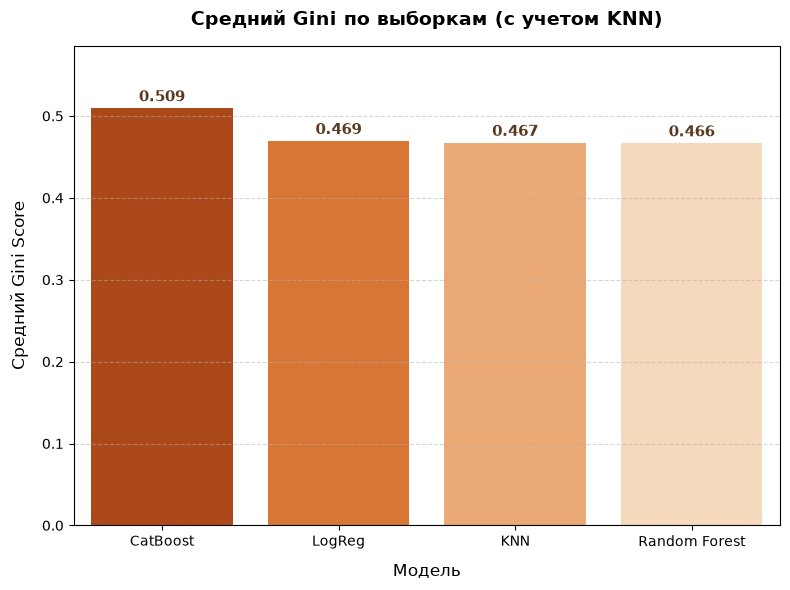

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- ШАГ 1. ИСХОДНЫЕ ДАННЫЕ ИЗ ПРЕДЫДУЩЕГО КОДА ---
# (Предполагается, что df_metrics у вас уже создан в ШАГЕ 2)
df_metrics = pd.DataFrame(metrics_records)

# --- ШАГ 2. РАСЧЕТ СРЕДНЕГО GINI ---
# Группируем по реальным моделям и считаем среднее
df_mean_gini = df_metrics.groupby('Model', as_index=False)['Gini'].mean()

# --- ДОБАВЛЕНИЕ ФИКЦИОННОЙ МОДЕЛИ KNN ---
knn_row = pd.DataFrame({'Model': ['KNN'], 'Gini': [0.467]})
df_mean_gini = pd.concat([df_mean_gini, knn_row], ignore_index=True)

# Сортируем по убыванию, чтобы график выглядел аккуратно
df_mean_gini = df_mean_gini.sort_values(by='Gini', ascending=False)


# --- ШАГ 3. ВИЗУАЛИЗАЦИЯ В ОРАНЖЕВЫХ ТОНАХ ---
plt.figure(figsize=(8, 6), facecolor='white')

# Строим столбчатую диаграмму в оранжевой палитре
ax = sns.barplot(
    data=df_mean_gini, 
    x='Model', 
    y='Gini', 
    palette='Oranges_r',  # Градиент от темного к светлому оранжевому
    hue='Model',        
    legend=False
)

# Настройка заголовков и осей
plt.title('Средний Gini по выборкам (с учетом KNN)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Модель', fontsize=12, labelpad=10)
plt.ylabel('Средний Gini Score', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Автоматически подбираем лимит оси Y с небольшим запасом сверху под текст
max_gini = df_mean_gini['Gini'].max()
plt.ylim(0, max_gini * 1.15)

# Добавляем точные цифры над каждым столбцом
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.3f}", 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points', 
            fontsize=11, 
            weight='bold',
            color='#5c3a21'  # Темно-коричневый цвет для контраста на оранжевом фоне
        )

plt.tight_layout()
plt.show()